
## RQ 6: Which teams scored goals most often at home turf in 2024?

In [7]:
import requests
import matplotlib.pyplot as plt

In [ ]:
response = requests.get("https://api.openligadb.de/getmatchdata/bl1/2024")
response = response.json()

# get all matchIDs of season 2024
matchIDs = []
for length in range(len(response)):
    match = response [length]
    matchID = match ['matchID']
    matchIDs.append(matchID)           # len = 306

# get all teamIDs of season 2024
# [0] teamID, [1] number goals home, [2] number goals away, [3] teamName
teamIDs = [[], [], [], []] 
for matchID in matchIDs:
    # get match 
    url = "https://api.openligadb.de/getmatchdata/"
    url += str(matchID)
    match = requests.get(url)
    match = match.json()

    # get both teams, if new add to teamIDs
    teamID1 = match ['team1'] ['teamId']
    teamID2 = match ['team2'] ['teamId']
    if teamID1 not in teamIDs[0]:
        teamIDs[0] += [teamID1]
        teamIDs[1] += [0]
        teamIDs[2] += [0]
        teamIDs[3] += [match ['team1'] ['teamName']]
    if teamID2 not in teamIDs[0]:
        teamIDs[0] += [teamID2]
        teamIDs[1] += [0]
        teamIDs[2] += [0]
        teamIDs[3] += [match ['team2'] ['teamName']]
    
    # get all goals in match and team that scored them 
    goals = match ['goals']
    score1 = 0
    score2 = 0
    for goal in goals:
        score1new = goal ['scoreTeam1'] 
        score2new = goal ['scoreTeam2']
        if score1new > score1: 
            # team1 is hometeam
            index = teamIDs [0].index(teamID1)
            teamIDs [1] [index] += 1
            score1 = score1new
        else:
            index = teamIDs [0].index(teamID2)
            teamIDs [2] [index] += 1
            score2 = score2new

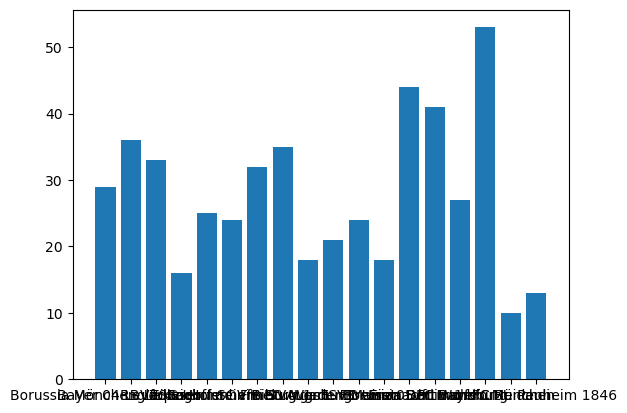

In [8]:
x = teamIDs[3]
y = teamIDs[1]
plt.bar(x,y)
plt.show()